In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

EXTRACTION_PATH = os.environ.get('EXTRACTION_PATH',
    '/share/pierson/matt/UAIR/outputs/2026-03-21_historical_norms/09-20-04/COLM_norms_fiction/outputs/extraction/structured_norms.parquet')

df = pd.read_parquet(EXTRACTION_PATH)

# Normalize object-typed bool columns upfront
df['norm_quality_passed'] = df['norm_quality_passed'].astype(bool)
df['raz_governs_info_flow'] = df['raz_governs_info_flow'].astype(str).str.lower().eq('true')

print(f'Loaded {len(df):,} rows from {EXTRACTION_PATH}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head(2)

Loaded 11,869 rows from /share/pierson/matt/UAIR/outputs/2026-03-21_historical_norms/09-20-04/COLM_norms_fiction/outputs/extraction/structured_norms.parquet
Columns (34): ['gutenberg_id', 'chunk_id', 'article_text', 'chunk_size', 'book_title', 'book_author', 'book_summary', 'generated_text', 'has_prescriptive_content', 'has_norms', 'norm_count', 'reasoning_trace', 'norm_snippet', 'preliminary_normative_force', 'governs_information_flow', 'reasoning_error', 'norm_index', 'raz_norm_count', 'extraction_failed', 'raz_prescriptive_element', 'raz_norm_subject', 'raz_norm_act', 'raz_condition_of_application', 'raz_normative_force', 'raz_norm_articulation', 'raz_norm_source', 'raz_governs_info_flow', 'raz_info_flow_note', 'raz_confidence_qual', 'raz_confidence_quant', 'raz_context', 'raz_norm_index', 'norm_quality_flags', 'norm_quality_passed']


,gutenberg_id,chunk_id,article_text,chunk_size,book_title,book_author,book_summary,generated_text,has_prescriptive_content,has_norms,...,raz_norm_articulation,raz_norm_source,raz_governs_info_flow,raz_info_flow_note,raz_confidence_qual,raz_confidence_quant,raz_context,raz_norm_index,norm_quality_flags,norm_quality_passed
0,1342,6,154\n\n“So much love and eloquence” ...,5911,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon...","{\n ""norms"": [\n {\n ""norm"": {\n ...",True,True,...,A single man in possession of a good fortune m...,implicit,False,None,somewhat_certain,6.0,interpersonal ethics,0.0,None,True
1,1342,6,154\n\n“So much love and eloquence” ...,5911,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon...","{\n ""norms"": [\n {\n ""norm"": {\n ...",True,True,...,Mr. Bennet must know about the new tenant of N...,implicit,True,"sender=Mrs. Long, recipient=Mr. Bennet, inform...",somewhat_certain,6.0,communal life,0.0,named_char_in_subject:bennet; named_char_in_ar...,False


In [2]:
n_chunks = df[['gutenberg_id', 'chunk_id']].drop_duplicates().shape[0]
n_norms = df['has_norms'].sum()
n_empty = (~df['has_norms']).sum()
n_errors = df['reasoning_error'].notna().sum()
n_extraction_failed = df['extraction_failed'].sum()
n_quality_passed = df['norm_quality_passed'].sum()
n_quality_flagged = len(df) - n_quality_passed

print(f'Total rows (one per norm):     {len(df):,}')
print(f'Unique chunks processed:       {n_chunks:,}')
print(f'Rows with norms:               {n_norms:,} ({n_norms/len(df)*100:.1f}%)')
print(f'Rows without norms:            {n_empty:,} ({n_empty/len(df)*100:.1f}%)')
print(f'Parse errors:                  {n_errors:,}')
print(f'Extraction failures:           {n_extraction_failed:,}')
print(f'Quality passed:                {n_quality_passed:,} ({n_quality_passed/len(df)*100:.1f}%)')
print(f'Quality flagged:               {n_quality_flagged:,} ({n_quality_flagged/len(df)*100:.1f}%)')
print(f'Avg norms per chunk:           {n_norms / n_chunks:.1f}')

Total rows (one per norm):     11,869
Unique chunks processed:       2,204
Rows with norms:               11,869 (100.0%)
Rows without norms:            0 (0.0%)
Parse errors:                  0
Extraction failures:           0
Quality passed:                8,963 (75.5%)
Quality flagged:               2,906 (24.5%)
Avg norms per chunk:           5.4


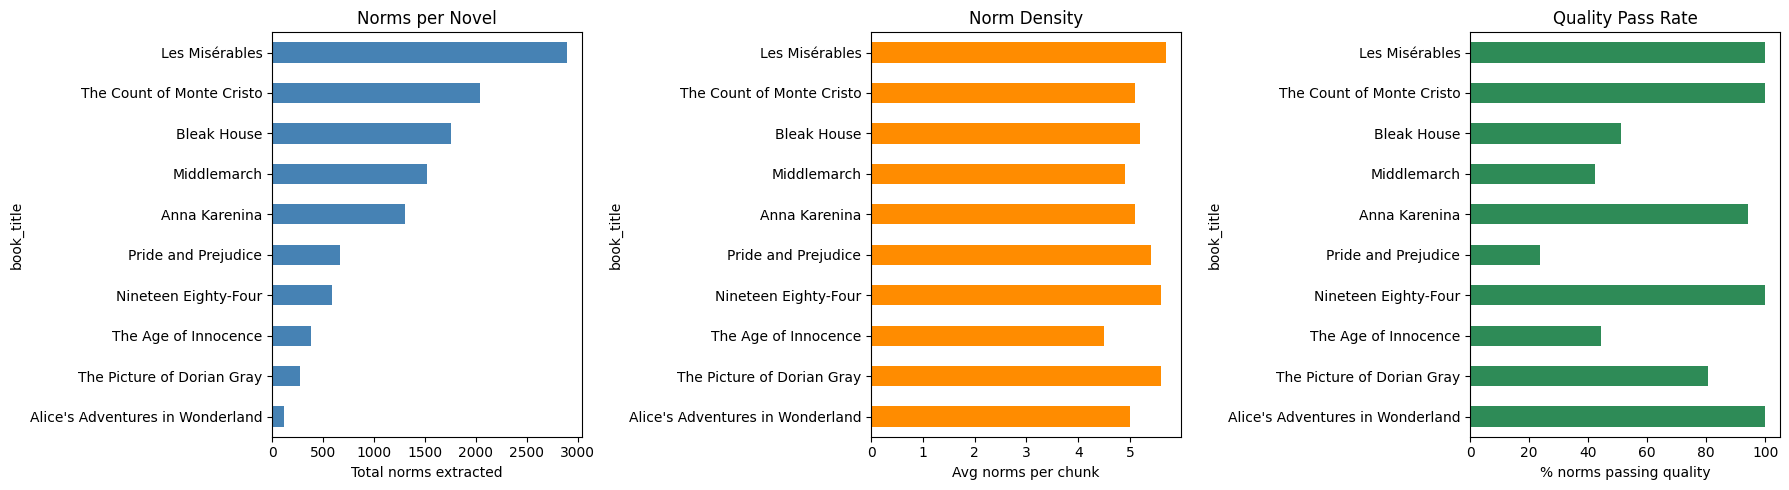

,total_norms,chunks_with_norms,quality_passed,info_flow_norms,total_chunks,norms_per_chunk,pct_quality_passed
book_title,,,,,,,
Les Misérables,2896,512,2891,193,512,5.7,99.8
The Count of Monte Cristo,2045,402,2044,288,402,5.1,100.0
Bleak House,1754,337,900,247,337,5.2,51.3
Middlemarch,1519,311,642,171,311,4.9,42.3
Anna Karenina,1308,255,1229,112,255,5.1,94.0
Pride and Prejudice,666,123,158,86,123,5.4,23.7
Nineteen Eighty-Four,589,106,589,84,106,5.6,100.0
The Age of Innocence,384,85,170,43,85,4.5,44.3
The Picture of Dorian Gray,272,49,219,26,49,5.6,80.5


In [3]:
norms_by_book = df[df['has_norms']].groupby('book_title').agg(
    total_norms=('raz_norm_index', 'count'),
    chunks_with_norms=('chunk_id', 'nunique'),
    quality_passed=('norm_quality_passed', 'sum'),
    info_flow_norms=('raz_governs_info_flow', 'sum'),
).sort_values('total_norms', ascending=True)

total_chunks = df[['book_title', 'gutenberg_id', 'chunk_id']].drop_duplicates().groupby('book_title').size()
norms_by_book['total_chunks'] = total_chunks
norms_by_book['norms_per_chunk'] = (norms_by_book['total_norms'] / norms_by_book['total_chunks']).round(1)
norms_by_book['pct_quality_passed'] = (norms_by_book['quality_passed'] / norms_by_book['total_norms'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

norms_by_book['total_norms'].plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total norms extracted')
axes[0].set_title('Norms per Novel')

norms_by_book['norms_per_chunk'].plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('Avg norms per chunk')
axes[1].set_title('Norm Density')

norms_by_book['pct_quality_passed'].plot.barh(ax=axes[2], color='seagreen')
axes[2].set_xlabel('% norms passing quality')
axes[2].set_title('Quality Pass Rate')

plt.tight_layout()
plt.show()

norms_by_book.sort_values('total_norms', ascending=False)

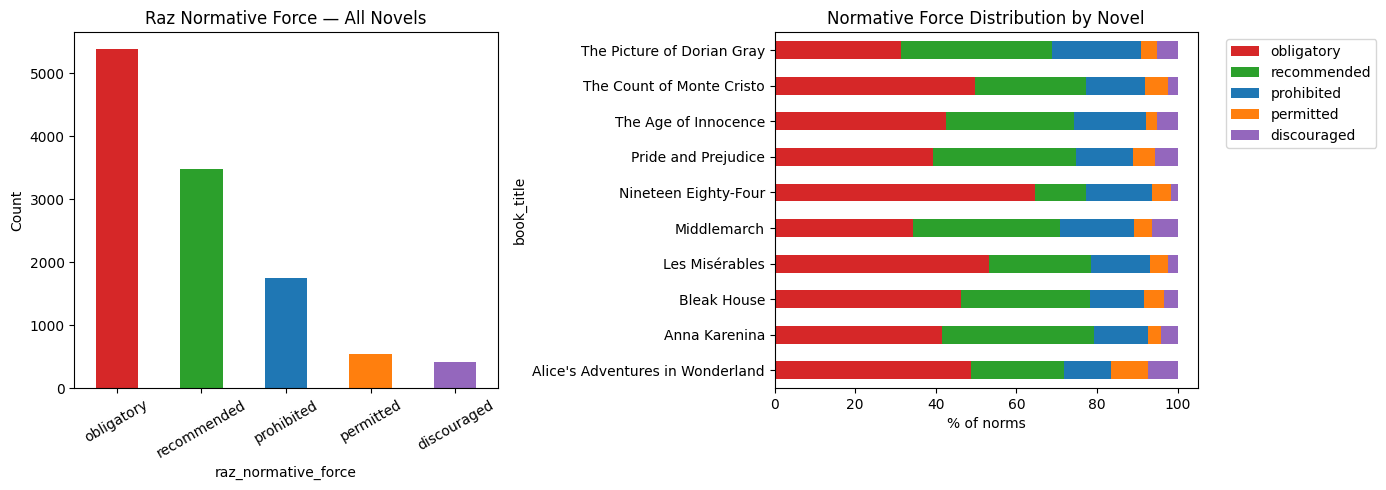

In [4]:
force_order = ['obligatory', 'recommended', 'prohibited', 'permitted', 'discouraged']
force_colors = {'obligatory': '#d62728', 'recommended': '#2ca02c', 'prohibited': '#1f77b4',
                'permitted': '#ff7f0e', 'discouraged': '#9467bd'}

has_norms = df[df['has_norms']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
force_counts = has_norms['raz_normative_force'].value_counts().reindex(force_order).dropna()
force_counts.plot.bar(ax=axes[0], color=[force_colors.get(f, 'gray') for f in force_counts.index])
axes[0].set_title('Raz Normative Force — All Novels')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Per novel (stacked %)
force_by_book = pd.crosstab(has_norms['book_title'], has_norms['raz_normative_force'])
force_by_book = force_by_book.reindex(columns=force_order, fill_value=0)
force_by_book_pct = force_by_book.div(force_by_book.sum(axis=1), axis=0) * 100
force_by_book_pct.sort_index().plot.barh(
    stacked=True, ax=axes[1],
    color=[force_colors.get(f, 'gray') for f in force_order]
)
axes[1].set_xlabel('% of norms')
axes[1].set_title('Normative Force Distribution by Novel')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Check for unexpected force values
unexpected = has_norms[~has_norms['raz_normative_force'].isin(force_order + [None])]['raz_normative_force'].unique()
if len(unexpected):
    print(f'Unexpected normative force values: {unexpected}')

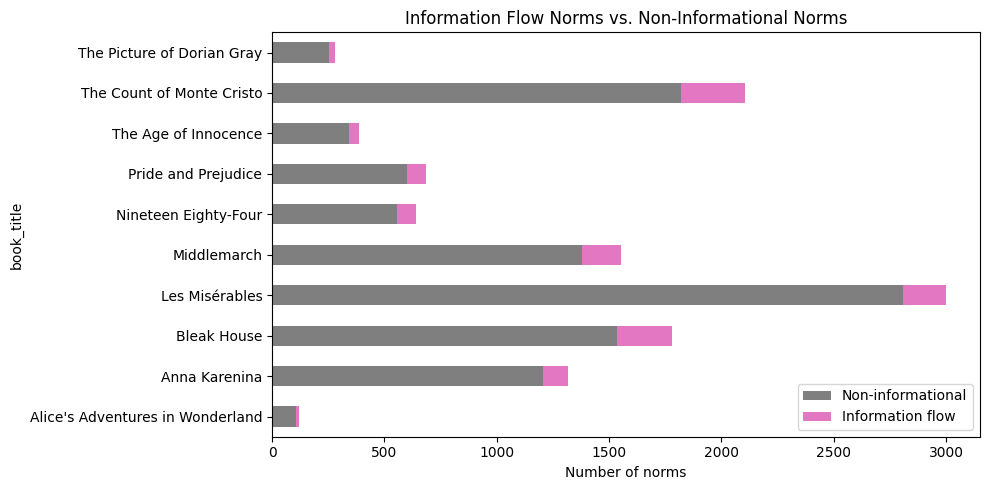

Information flow norms: 1,265 / 11,869 (10.7%)

Info flow notes available: 1,265

Sample info flow notes:
  - sender=individual, recipient=authorities, information_type=incriminating evidence, transmission_principle=concealment
  - sender=Albert, recipient=Monte Cristo, information_type=intention to seek revenge, transmission_principle=clarity
  - sender=Richard, recipient=Ada, information_type=personal assurance, transmission_principle=trust and reassurance
  - sender=Monte Cristo, recipient=authorities, information_type=relevant information, transmission_principle=truthfulness
  - sender=club porter, recipient=member, information_type=status of other members



,info_flow_count,total,non_info_count,info_flow_pct
book_title,,,,
Bleak House,247,1782,1535,13.9
The Count of Monte Cristo,288,2107,1819,13.7
Nineteen Eighty-Four,84,641,557,13.1
Pride and Prejudice,86,685,599,12.6
Alice's Adventures in Wonderland,15,121,106,12.4
The Age of Innocence,43,385,342,11.2
Middlemarch,171,1552,1381,11.0
The Picture of Dorian Gray,26,278,252,9.4
Anna Karenina,112,1317,1205,8.5


In [5]:
has_norms = df[df['has_norms']].copy()

flow_by_book = has_norms.groupby('book_title')['raz_governs_info_flow'].agg(
    info_flow_count='sum',
    total='count'
)
flow_by_book['non_info_count'] = flow_by_book['total'] - flow_by_book['info_flow_count']
flow_by_book['info_flow_pct'] = (flow_by_book['info_flow_count'] / flow_by_book['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
flow_by_book[['non_info_count', 'info_flow_count']].sort_index().plot.barh(
    stacked=True, ax=ax, color=['#7f7f7f', '#e377c2']
)
ax.set_xlabel('Number of norms')
ax.set_title('Information Flow Norms vs. Non-Informational Norms')
ax.legend(['Non-informational', 'Information flow'], loc='lower right')
plt.tight_layout()
plt.show()

total_info = has_norms['raz_governs_info_flow'].sum()
total = len(has_norms)
print(f'Information flow norms: {total_info:,} / {total:,} ({total_info/total*100:.1f}%)')
print()
# Show info flow notes for a sample
info_notes = has_norms[has_norms['raz_governs_info_flow'] & has_norms['raz_info_flow_note'].notna()]['raz_info_flow_note']
print(f'Info flow notes available: {len(info_notes):,}')
if len(info_notes) > 0:
    print('\nSample info flow notes:')
    for note in info_notes.sample(min(5, len(info_notes)), random_state=42):
        print(f'  - {note[:150]}')

print()
flow_by_book.sort_values('info_flow_pct', ascending=False)

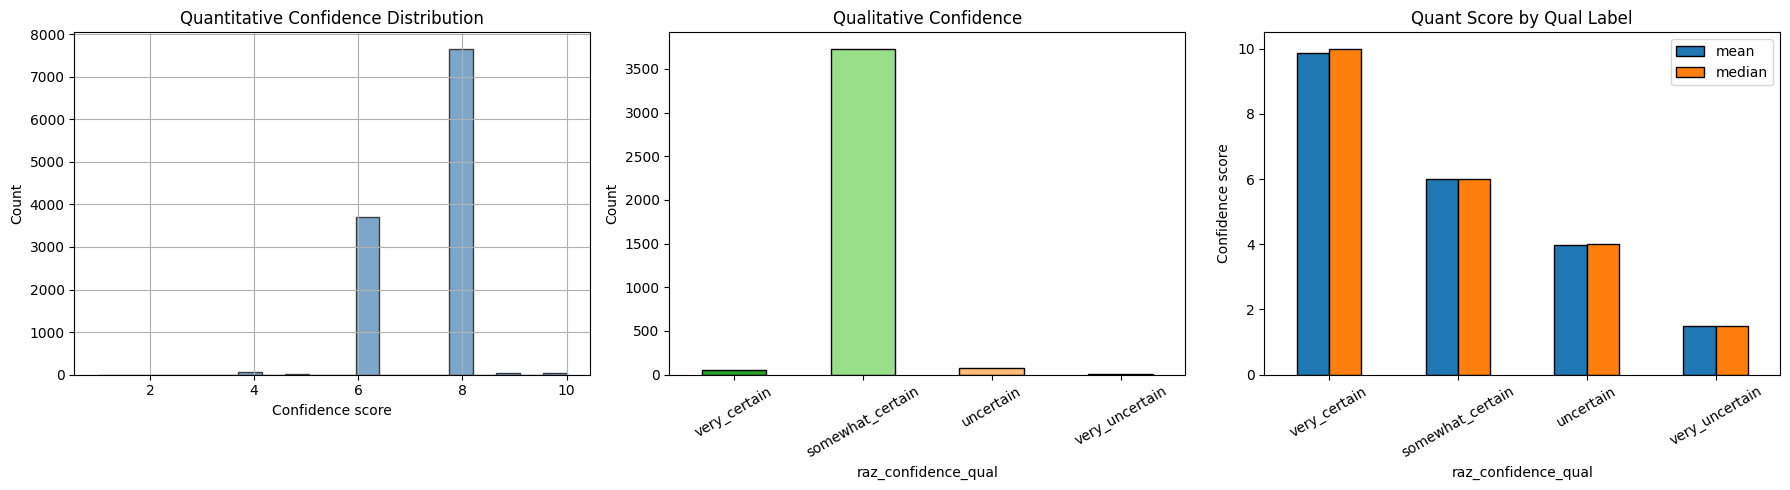

Confidence stats:
count    11554.00
mean         7.34
std          0.99
min          1.00
25%          6.00
50%          8.00
75%          8.00
max         10.00
Name: raz_confidence_quant, dtype: float64

Qualitative breakdown:
raz_confidence_qual
certain             7693
somewhat_certain    3733
uncertain             73
very_certain          53
very_uncertain         2
Name: count, dtype: int64


In [6]:
has_norms = df[df['has_norms']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantitative confidence histogram
has_norms['raz_confidence_quant'].hist(bins=20, ax=axes[0], edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Confidence score')
axes[0].set_ylabel('Count')
axes[0].set_title('Quantitative Confidence Distribution')

# Qualitative confidence breakdown
qual_order = ['very_certain', 'somewhat_certain', 'uncertain', 'very_uncertain']
qual_counts = has_norms['raz_confidence_qual'].value_counts().reindex(qual_order).dropna()
qual_counts.plot.bar(ax=axes[1], color=['#2ca02c', '#98df8a', '#ffbb78', '#d62728'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Qualitative Confidence')
axes[1].tick_params(axis='x', rotation=30)

# Quant vs. qual agreement
conf_cross = has_norms.groupby('raz_confidence_qual')['raz_confidence_quant'].agg(['mean', 'median', 'std']).reindex(qual_order).dropna()
conf_cross[['mean', 'median']].plot.bar(ax=axes[2], edgecolor='black')
axes[2].set_ylabel('Confidence score')
axes[2].set_title('Quant Score by Qual Label')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Confidence stats:')
print(has_norms['raz_confidence_quant'].describe().round(2))
print()
print('Qualitative breakdown:')
print(has_norms['raz_confidence_qual'].value_counts())

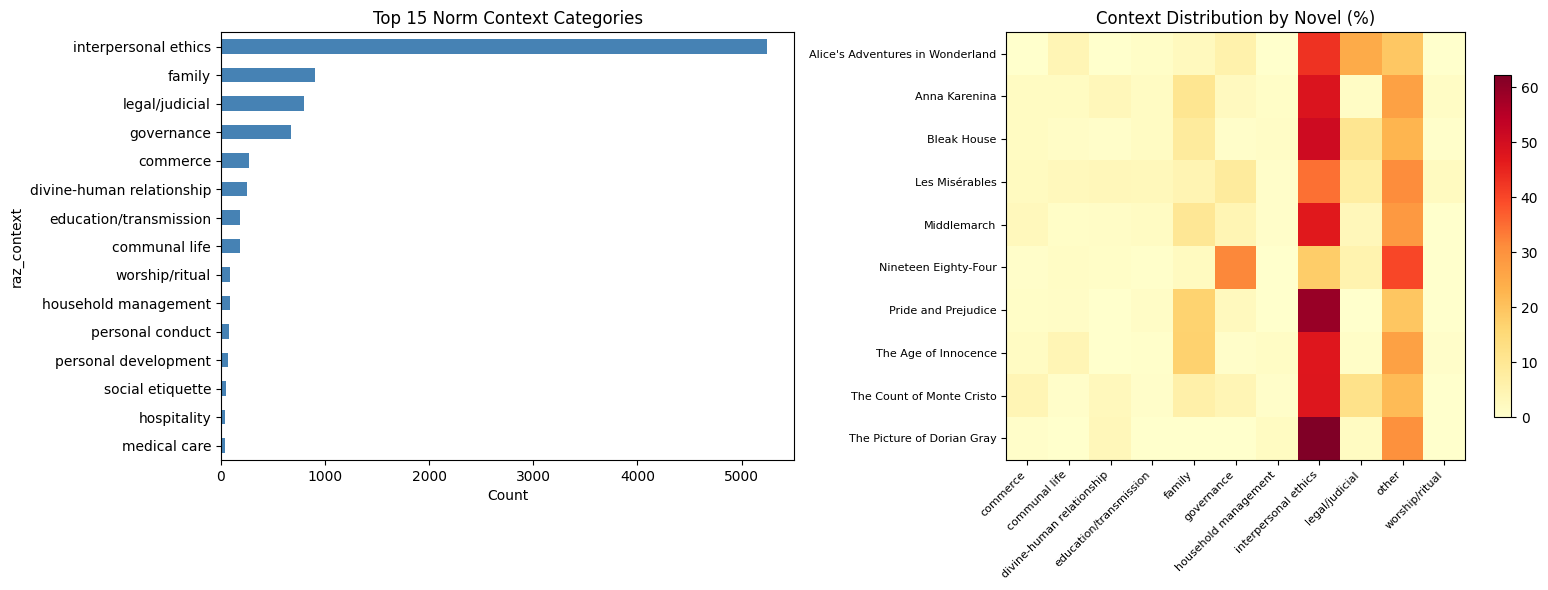

Unique context values: 1065

Full context distribution:
raz_context
interpersonal ethics                                                                            5244
family                                                                                           903
legal/judicial                                                                                   803
governance                                                                                       671
commerce                                                                                         267
divine-human relationship                                                                        249
education/transmission                                                                           189
communal life                                                                                    184
worship/ritual                                                                                    91
household management   

In [7]:
has_norms = df[df['has_norms']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top context categories
context_counts = has_norms['raz_context'].value_counts().head(15)
context_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Norm Context Categories')
axes[0].invert_yaxis()

# Context by novel (heatmap of top 10 contexts)
top_contexts = has_norms['raz_context'].value_counts().head(10).index
context_by_book = pd.crosstab(
    has_norms['book_title'],
    has_norms['raz_context'].where(has_norms['raz_context'].isin(top_contexts), other='other')
)
context_by_book_pct = context_by_book.div(context_by_book.sum(axis=1), axis=0) * 100
im = axes[1].imshow(context_by_book_pct.values, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(len(context_by_book_pct.columns)))
axes[1].set_xticklabels(context_by_book_pct.columns, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(len(context_by_book_pct.index)))
axes[1].set_yticklabels(context_by_book_pct.index, fontsize=8)
axes[1].set_title('Context Distribution by Novel (%)')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print(f'Unique context values: {has_norms["raz_context"].nunique()}')
print()
print('Full context distribution:')
print(has_norms['raz_context'].value_counts().to_string())

Quality-flagged norms: 2,906 / 11,869 (24.5%)

Flag distribution:
titled_name_in_subject; titled_name_in_articulation                                                                                                                                                                                                                                                                                                                                                                 459
titled_name_in_subject; titled_name_in_condition; titled_name_in_articulation                                                                                                                                                                                                                                                                                                                                       146
named_char_in_subject:dorothea; named_char_in_articulation:dorothea                                                   

/tmp/ipykernel_1329626/3971219905.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


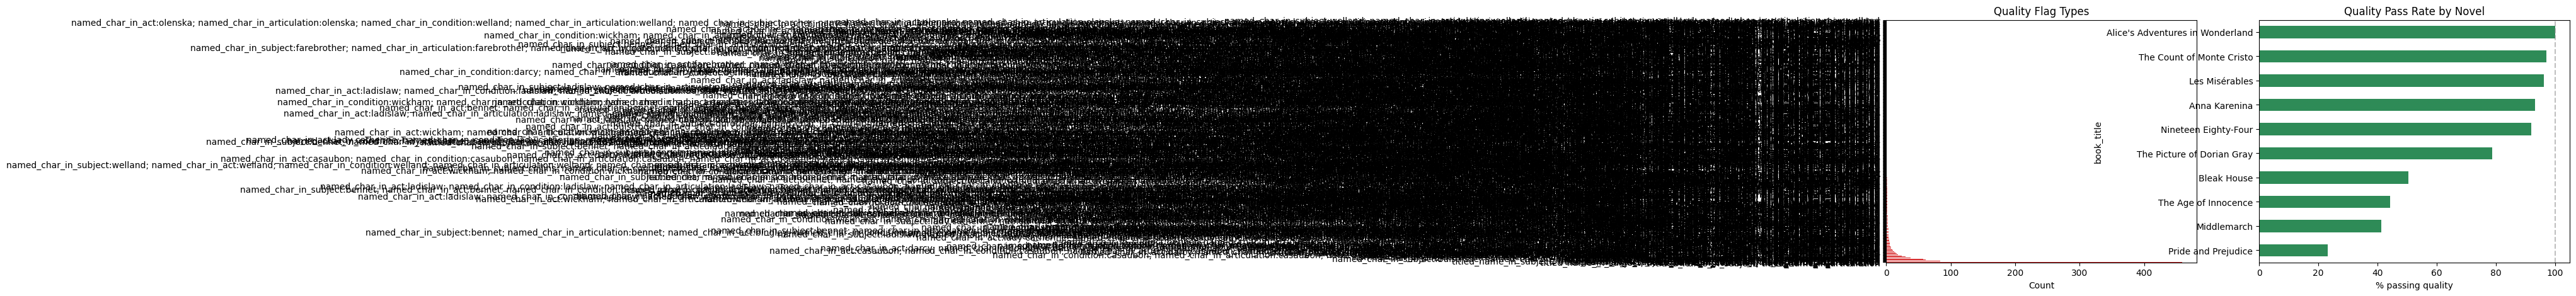


Sample flagged norms:
  [Pride and Prejudice] Jane ought to consider the opinions of Mr. Bingley's sisters and friends before accepting his affection when they are op
    Flags: named_char_in_act:bingley; named_char_in_condition:bingley; named_char_in_articulation:bingley; titled_name_in_act; titled_name_in_condition; titled_name_in_articulation

  [Middlemarch] Lydgate ought not to show an unpleasant temper after making painful propositions to Rosamond.
    Flags: named_char_in_subject:lydgate; named_char_in_articulation:lydgate; named_char_in_condition:rosamond; named_char_in_articulation:rosamond

  [Pride and Prejudice] Elizabeth (Lizzy) should walk out with Mr. Darcy when he is present and looking for a companion
    Flags: named_char_in_act:darcy; named_char_in_condition:darcy; named_char_in_articulation:darcy; named_char_in_subject:elizabeth; named_char_in_articulation:elizabeth; titled_name_in_act; titled_name_in_condition; titled_name_in_articulation

  [Bleak House] The youn

In [8]:
has_norms = df[df['has_norms']].copy()
flagged = has_norms[~has_norms['norm_quality_passed']]

print(f'Quality-flagged norms: {len(flagged):,} / {len(has_norms):,} ({len(flagged)/len(has_norms)*100:.1f}%)')
print()

# Parse flags (may be a string repr of a list or a list)
import ast

def parse_flags(x):
    if pd.isna(x) or x is None:
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return [str(x)]

flagged_flags = flagged['norm_quality_flags'].apply(parse_flags)
all_flags = [f for flags in flagged_flags for f in flags]

print('Flag distribution:')
flag_counts = pd.Series(all_flags).value_counts()
print(flag_counts.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flag_counts.plot.barh(ax=axes[0], color='#d62728')
axes[0].set_xlabel('Count')
axes[0].set_title('Quality Flag Types')

# Quality pass rate by novel
quality_by_book = has_norms.groupby('book_title')['norm_quality_passed'].agg(
    passed='sum',
    total='count'
)
quality_by_book['pass_rate'] = (quality_by_book['passed'] / quality_by_book['total'] * 100).round(1)
quality_by_book['pass_rate'].sort_values().plot.barh(ax=axes[1], color='seagreen')
axes[1].set_xlabel('% passing quality')
axes[1].set_title('Quality Pass Rate by Novel')
axes[1].axvline(100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Sample flagged norms
print('\nSample flagged norms:')
for _, row in flagged.sample(min(5, len(flagged)), random_state=42).iterrows():
    print(f'  [{row["book_title"]}] {row["raz_norm_articulation"][:120]}')
    print(f'    Flags: {row["norm_quality_flags"]}')
    print()

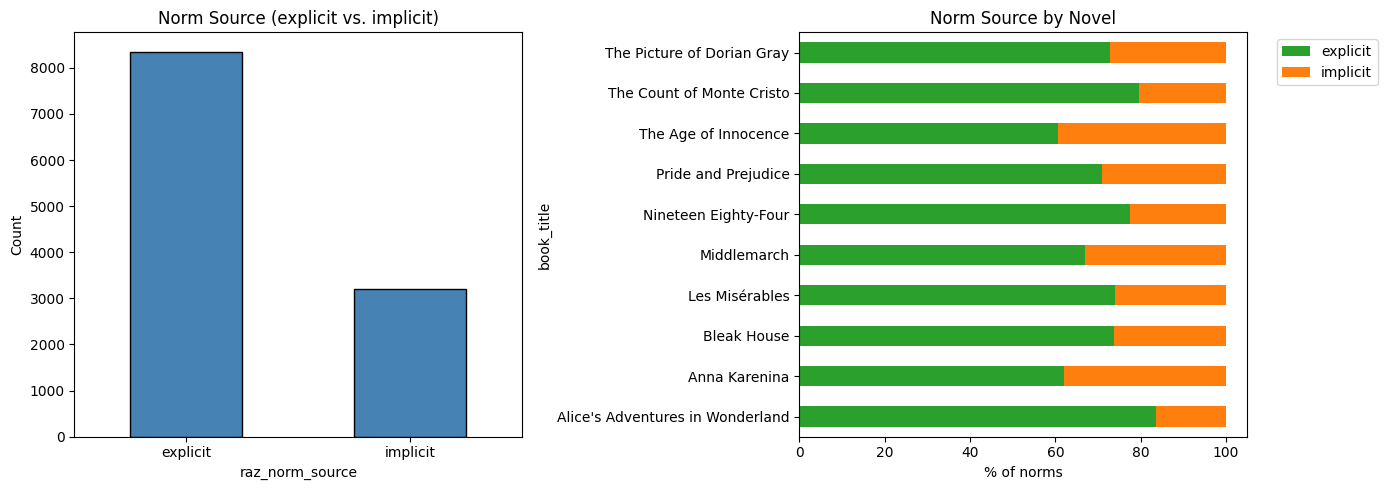

raz_norm_source
explicit    8351
implicit    3203
Name: count, dtype: int64


In [9]:
has_norms = df[df['has_norms']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = has_norms['raz_norm_source'].value_counts()
source_counts.plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Norm Source (explicit vs. implicit)')
axes[0].tick_params(axis='x', rotation=0)

# Source by novel
source_by_book = pd.crosstab(has_norms['book_title'], has_norms['raz_norm_source'])
source_by_book_pct = source_by_book.div(source_by_book.sum(axis=1), axis=0) * 100
source_by_book_pct.sort_index().plot.barh(stacked=True, ax=axes[1], color=['#2ca02c', '#ff7f0e'])
axes[1].set_xlabel('% of norms')
axes[1].set_title('Norm Source by Novel')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(source_counts)

In [10]:
sample_books = ['Pride and Prejudice', 'Nineteen Eighty-Four', 'Les Misérables',
                'Anna Karenina', 'Alice\'s Adventures in Wonderland']

for book in sample_books:
    subset = df[(df['book_title'] == book) & df['has_norms'] & df['norm_quality_passed']]
    if subset.empty:
        continue
    row = subset.sample(1, random_state=42).iloc[0]
    print(f'{"═" * 80}')
    print(f'{book} — chunk {row["chunk_id"]}, norm {int(row.get("raz_norm_index", 0))}')
    print(f'Force: {row["raz_normative_force"]} | Source: {row["raz_norm_source"]} | '
          f'Context: {row["raz_context"]} | Confidence: {row["raz_confidence_qual"]} ({row["raz_confidence_quant"]})')
    print(f'{"─" * 80}')
    print(f'Subject:     {row["raz_norm_subject"]}')
    print(f'Act:         {row["raz_norm_act"]}')
    print(f'Condition:   {row["raz_condition_of_application"]}')
    print(f'Presc. elem: {row["raz_prescriptive_element"]}')
    print(f'Info flow:   {row["raz_governs_info_flow"]}', end='')
    if row.get('raz_info_flow_note'):
        print(f' — {row["raz_info_flow_note"]}')
    else:
        print()
    print(f'{"─" * 80}')
    print(f'Articulation: {row["raz_norm_articulation"]}')
    print(f'{"─" * 80}')
    trace = str(row.get('reasoning_trace', ''))
    if trace and trace != 'None':
        print(f'Reasoning ({len(trace)} chars): {trace[:400]}')
        if len(trace) > 400:
            print('...')
    print()

════════════════════════════════════════════════════════════════════════════════
Pride and Prejudice — chunk 119, norm 0
Force: obligatory | Source: explicit | Context: interpersonal ethics | Confidence: certain (8.0)
────────────────────────────────────────────────────────────────────────────────
Subject:     a family member
Act:         offer arguments and words of comfort
Condition:   when a family member is in distress, particularly due to a significant and lasting misfortune
Presc. elem: ought to
Info flow:   False
────────────────────────────────────────────────────────────────────────────────
Articulation: A family member ought to offer arguments and words of comfort when a family member is in distress, particularly due to a significant and lasting misfortune.
────────────────────────────────────────────────────────────────────────────────
Reasoning (473 chars): The norm subject is Mr. Collins, who is obligated to provide comfort and support to Mr. Bennet. The prescriptive eleme

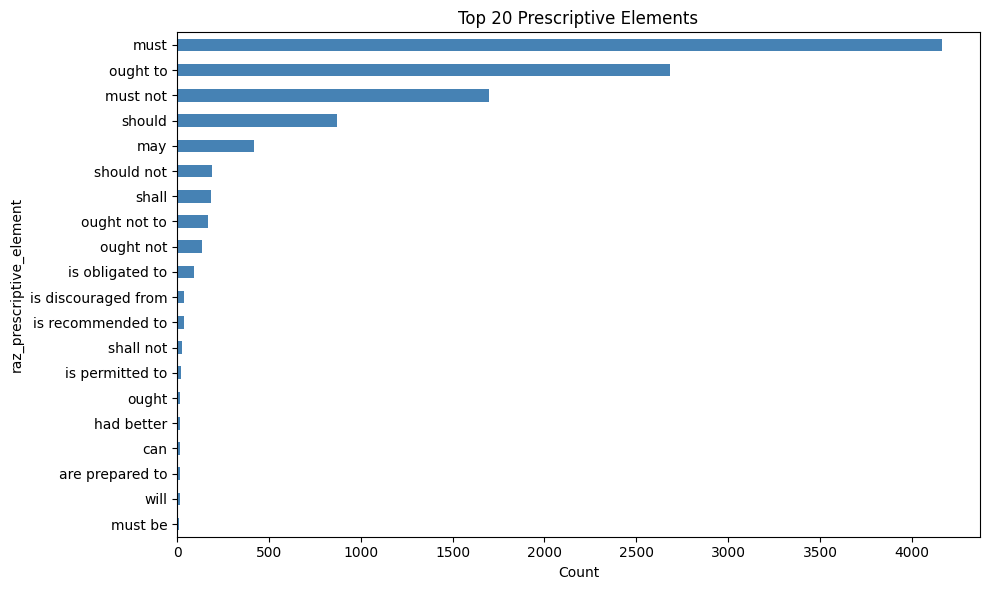

Unique prescriptive elements: 544

raz_prescriptive_element
must                   4163
ought to               2686
must not               1697
should                  871
may                     417
should not              192
shall                   187
ought not to            168
ought not               136
is obligated to          93
is discouraged from      40
is recommended to        40
shall not                25
is permitted to          22
ought                    18
had better               17
can                      15
are prepared to          14
will                     14
must be                  11


In [11]:
has_norms = df[df['has_norms']]

presc_counts = has_norms['raz_prescriptive_element'].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
presc_counts.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Top 20 Prescriptive Elements')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Unique prescriptive elements: {has_norms["raz_prescriptive_element"].nunique()}')
print()
print(presc_counts.to_string())

In [12]:
errors = df[df['reasoning_error'].notna()]
extraction_failed = df[df['extraction_failed']]

print(f'Parse errors: {len(errors)}')
for _, row in errors.iterrows():
    print(f'  [{row["book_title"]}, chunk {row["chunk_id"]}]: {row["reasoning_error"]}')
    print(f'  Raw output (first 300 chars): {str(row["generated_text"])[:300]}')
    print()

print(f'Extraction failures: {len(extraction_failed)}')
if len(extraction_failed) > 0:
    print(extraction_failed[['book_title', 'chunk_id', 'reasoning_error']].to_string())


Parse errors: 0
Extraction failures: 0


In [13]:
clean = df[df['has_norms'] & df['norm_quality_passed']]
n_clean = len(clean)
n_books = clean['book_title'].nunique()
n_clean_chunks = clean[['gutenberg_id', 'chunk_id']].drop_duplicates().shape[0]
n_info_flow = clean['raz_governs_info_flow'].sum()

print('=' * 60)
print('QUALITY-FILTERED EXTRACTION SUMMARY')
print('=' * 60)
print(f'Norms (quality-passed):   {n_clean:,}')
print(f'Novels:                   {n_books}')
print(f'Unique chunks:            {n_clean_chunks:,}')
print(f'Information flow norms:   {n_info_flow:,} ({n_info_flow/n_clean*100:.1f}%)')
print(f'Median confidence:        {clean["raz_confidence_quant"].median():.1f}')
print()
print('Per-novel breakdown:')
summary = clean.groupby('book_title').agg(
    norms=('raz_norm_index', 'count'),
    info_flow=('raz_governs_info_flow', 'sum'),
    median_conf=('raz_confidence_quant', 'median'),
).sort_values('norms', ascending=False)
summary['info_flow_pct'] = (summary['info_flow'] / summary['norms'] * 100).round(1)
print(summary.to_string())

QUALITY-FILTERED EXTRACTION SUMMARY
Norms (quality-passed):   8,963
Novels:                   10
Unique chunks:            1,924
Information flow norms:   892 (10.0%)
Median confidence:        8.0

Per-novel breakdown:
                                  norms  info_flow  median_conf  info_flow_pct
book_title                                                                    
Les Misérables                     2891        193          8.0            6.7
The Count of Monte Cristo          2044        288          8.0           14.1
Anna Karenina                      1229        101          8.0            8.2
Bleak House                         900        111          8.0           12.3
Middlemarch                         642         50          8.0            7.8
Nineteen Eighty-Four                589         84          8.0           14.3
The Picture of Dorian Gray          219         21          8.0            9.6
The Age of Innocence                170         12          8.0       

## 12. Summary: quality-filtered corpus stats

## 11. Parse errors & extraction failures

## 10. Prescriptive element distribution

## 9. Sample extracted norm articulations

## 8. Norm source distribution

## 7. Quality flags analysis

## 6. Norm context categories

## 5. Confidence distribution

## 4. Information flow norms

## 3. Raz normative force distribution

## 2. Norms per novel

## 1. Corpus overview

# COLM Norm Extraction — Exploratory Analysis

Explores the structured norm extraction output from Qwen2.5-72B-AWQ on 10 fiction novels.
Each row is one extracted Raz norm (exploded from chunk-level output), with structured fields
for norm subject, act, condition, normative force, confidence, and quality flags.